In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from matplotlib.ticker import MultipleLocator

In [ ]:
arr0 = np.load("..\Data\MAC_SWEEP\Bank0_1x_CD_Sweep_4.npy")
arr1 = np.load("..\Data\MAC_SWEEP\Bank1_1x_CD_Sweep_4.npy")
arr2 = np.load("..\Data\MAC_SWEEP\Bank2_1x_CD_Sweep_4.npy")
arr3 = np.load("..\Data\MAC_SWEEP\Bank3_1x_CD_Sweep_4.npy")
arr = np.concatenate((arr0, arr1, arr2, arr3), axis=1)
print(arr.shape)
test_arr = arr.reshape(arr.shape[0],16,int(arr.shape[1]/16))
for i in range(arr.shape[0]):
    for j in range(16):
        if(np.all(test_arr[i,j,:]==0)):
            print("Problem",i,j)


In [ ]:
arr0 = np.load("..\Data\MAC_SWEEP\Bank0_2x_CD_Sweep_4.npy")
arr1 = np.load("..\Data\MAC_SWEEP\Bank1_2x_CD_Sweep_4.npy")
arr2 = np.load("..\Data\MAC_SWEEP\Bank2_2x_CD_Sweep_4.npy")
arr3 = np.load("..\Data\MAC_SWEEP\Bank3_2x_CD_Sweep_4.npy")
arr = np.concatenate((arr3,arr2,arr1,arr0), axis=1)
print(arr.shape)
test_arr = arr.reshape(arr.shape[0],16,int(arr.shape[1]/16))
for i in range(arr.shape[0]):
    for j in range(16):
        if(np.all(test_arr[i,j,:]==0)):
            print("Problem",i,j)


In [ ]:
arr0 = np.load("..\Data\MAC_SWEEP\Bank0_4x_CD_Sweep_4.npy")
arr1 = np.load("..\Data\MAC_SWEEP\Bank1_4x_CD_Sweep_4.npy")
arr2 = np.load("..\Data\MAC_SWEEP\Bank2_4x_CD_Sweep_4.npy")
arr3 = np.load("..\Data\MAC_SWEEP\Bank3_4x_CD_Sweep_4.npy")
arr = np.concatenate((arr0,arr1,arr2,arr3), axis=1)
print(arr.shape)
test_arr = arr.reshape(arr.shape[0],16,int(arr.shape[1]/16))
for i in range(arr.shape[0]):
    for j in range(16):
        if(np.all(test_arr[i,j,:]==0)):
            print("Problem",i,j)



In [ ]:
arr0 = np.load("..\Data\MAC_SWEEP\Bank1_8x_CD_Sweep_4.npy")
arr1 = np.load("..\Data\MAC_SWEEP\Bank1_8x_CD_Sweep_4.npy")
arr2 = np.load("..\Data\MAC_SWEEP\Bank1_8x_CD_Sweep_4.npy")
arr3 = np.load("..\Data\MAC_SWEEP\Bank1_8x_CD_Sweep_4.npy")
arr = np.concatenate((arr3,arr2,arr1,arr0), axis=1)
print(arr.shape)
test_arr = arr.reshape(arr.shape[0],16,int(arr.shape[1]/16))
for i in range(arr.shape[0]):
    for j in range(16):
        if(np.all(test_arr[i,j,:]==0)):
            print("Problem",i,j)

In [4]:

arr1 = np.load("..\Data\MAC_SWEEP\Bank1_4x_CD_Sweep_1_Ref256_900.npy")
arr = np.concatenate((arr1,arr1,arr1,arr1), axis=1)
print(arr1.shape)
test_arr = arr.reshape(arr.shape[0],16,int(arr.shape[1]/16))
for i in range(arr.shape[0]):
    for j in range(16):
        if(np.all(test_arr[i,j,:]==0)):
            print("Problem",i,j)

(257, 64)


In [ ]:
arr = np.load("d:\Chip2025_Testing\Python_Notebook\Tests\Data\Temp.npy")
print(arr.shape)
test_arr = arr.reshape(arr.shape[0],16,int(arr.shape[1]/16))
for i in range(arr.shape[0]):
    for j in range(16):
        if(np.all(test_arr[i,j,:]==0)):
            print("Problem",i,j)

In [ ]:
temp = arr[:][0]
print(temp[0:64])
print(temp[64:128])
print(temp[128:192])
print(temp[192:256])

(257, 256)


C:\Users\dsdl\AppData\Local\Temp\ipykernel_400448\1846919691.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Blues')
C:\Users\dsdl\AppData\Local\Temp\ipykernel_400448\1846919691.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap2 = cm.get_cmap('Greens')


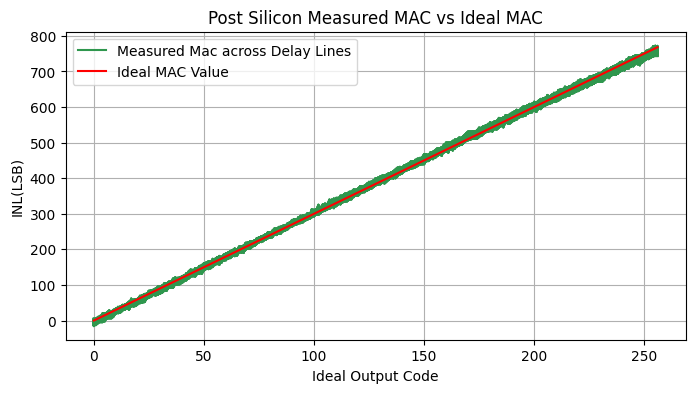

In [6]:
mult = 3
ideal_mac = np.arange(0,256*mult+0.5,1*mult)
x_axis = np.arange(0,257,1)
len(ideal_mac)
print(arr.shape)
corrected = []
error = []
cmap = cm.get_cmap('Blues')
cmap2 = cm.get_cmap('Greens')
fig, ax = plt.subplots(figsize=(8, 4))
plt.title("Post Silicon Measured MAC vs Ideal MAC")
plt.xlabel("Ideal Output Code")
plt.ylabel("INL(LSB)")
slope = []
bias = []
for i in range(0,arr.shape[1],1): #arr.shape[1]
    #if arr[:,i] < 0 : d1 = 32 - arr[:,i]
    #else: d1 = 32 + arr[:,i] 
    d1 = arr[:, i]
    m, c = np.polyfit(d1,ideal_mac , 1)
    slope.append(m)
    bias.append(c)
    d2 = d1*m+c 
    #plt.plot(ideal_mac, d1, color = cmap(0.3))
    plt.plot(x_axis, d2, color = cmap2(0.7))
    corrected.append(d2)
    error.append(d2 - ideal_mac)
corrected = np.array(corrected)
'''
for point in [50,130,240]:
    mean = np.mean(corrected[:,round(point/4)])
    std = np.std(corrected[:,round(point/4)])
    # Main plot arrow (pointing to feature of interest)
    point = point*mult
    ax.text(point,point-10,f'σ={std:0.3f}',
                fontsize=10)
    ax.errorbar(point, point, yerr=std*5, fmt='o', color='blue', capsize=5, markersize=3)
'''
plt.plot(x_axis, d2, color = cmap2(0.7), label = "Measured Mac across Delay Lines")
plt.plot(x_axis, ideal_mac,color = "Red", label = "Ideal MAC Value")
plt.legend() 
plt.grid(True)
plt.show()

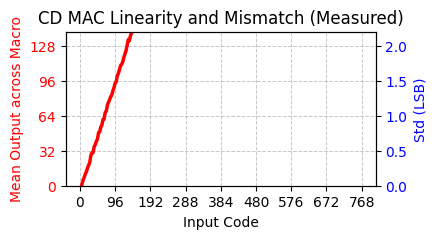

In [7]:
mean_corrected = np.mean(corrected,axis=0)
std_corrected = np.std(corrected,axis=0)
#std_corrected = std_corrected[:len(std_corrected)-5]
#std_corrected[len(std_corrected)-6:len(std_corrected)] = std_corrected[len(std_corrected)-6]
fig, ax1 = plt.subplots(figsize=(4, 2))

# First plot (left y-axis)
ax1.plot(x_axis*3, mean_corrected, color="r",linewidth=2.5)
ax1.set_xlabel("Input Code")
ax1.set_ylabel("Mean Output across Macro", color="r")
ax1.tick_params(axis="y", labelcolor="r")
ax1.set_ylim(0, 140.8)
ax1.yaxis.set_major_locator(MultipleLocator(32))

# Second plot (right y-axis)
ax2 = ax1.twinx()
ax2.plot( x_axis*3,std_corrected, color="b",alpha=0.5,linewidth=2.5)
ax2.set_ylabel("Std (LSB)", color="b")
ax2.tick_params(axis="y", labelcolor="b")
ax2.set_ylim(0, 2.2)
ax2.yaxis.set_major_locator(MultipleLocator(0.5))



plt.xticks(range(0, 256*3+1,32*3)) 
# Optional: title
plt.title("CD MAC Linearity and Mismatch (Measured)")
ax1.grid(True, which='major', linestyle='--', linewidth=0.7, alpha=0.7)
ax1.grid(True, which='minor', linestyle=':', linewidth=0.5, alpha=0.5)
#plt.savefig("D:\ISSCC_26\Graphs\CD_2x_Acc.jpg", dpi=800, bbox_inches="tight")
plt.show()

In [ ]:
print(np.mean(std_corrected))

In [ ]:
arr1 = np.load("..\Data\MAC_SWEEP\Bank1_4x_CD_Sweep_1_Ref256_900.npy")
arr2 = np.load("..\Data\MAC_SWEEP\Bank1_4x_CD_Sweep_1_Ref256_800.npy")
arr3 = np.load("..\Data\MAC_SWEEP\Bank1_4x_CD_Sweep_1_Ref256_700.npy")
arr = np.concatenate((arr1,arr2,arr3),axis=1)
print(arr1.shape,arr2.shape,arr3.shape,arr.shape)
#arr1 = np.transpose(arr1)
temp = []
for i in range(0,arr.shape[1],1): #arr.shape[1]
    if(np.floor(i/64) == 0):
        factor = 1
        x_axis = np.arange(0,257,1)
    if(np.floor(i/64) == 1):
        factor = 3/2
        x_axis = np.arange(0,256*2/3+2/3,2/3)
    if(np.floor(i/64) == 2):
        factor = 3
        x_axis = np.arange(0,256*1/3+1/3,1/3)
    out = (arr[:,i] * slope[i%64]  + bias[i%64])
    temp.append(out)
    plt.plot(out)
print(np.mean(np.std(temp,axis=0)))

In [13]:
corrected_mac = np.transpose(corrected)
print(corrected_mac.shape)
corrected_mac = np.reshape(corrected_mac,(257,4,64))
#corrected_mac = corrected_mac[:,:,0,:]
corrected_mac.shape

(257, 256)


(257, 4, 64)

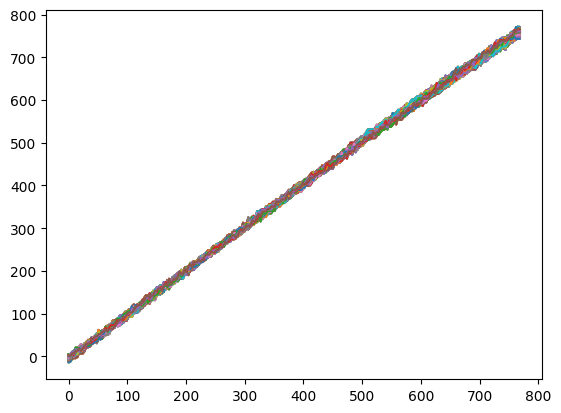

In [15]:
HW_MODEL_CD_1x = np.zeros(((4,64,256*mult+1)),dtype=np.float32)
x_new = np.arange(0, 256*mult+1, 1)   # length 257
x_orig = np.arange(0, 256*mult+1, 1*mult)  # length 65
# Interpolation
for bank in range(4):
    for dl in range(64):
        a = corrected_mac[:,bank,dl]
        HW_MODEL_CD_1x[bank,dl] = np.interp(x_new, x_orig, a)
        plt.plot(HW_MODEL_CD_1x[bank,dl])
#np.save("d:\Chip2025\Chip2025_Testing\Python_Notebook\Tests\Data\Hardware_Model\HW_MODEL_CD_8x_Ref256_sweep4.npy",HW_MODEL_CD_1x)

In [17]:
print(HW_MODEL_CD_1x[:,3,50])


[46.915447 46.915447 46.915447 46.915447]


In [ ]:
sigma = []
for i in range(0,arr.shape[1],1):
    plt.plot(ideal_mac, error[i], label='Data', color = cmap2(0.7))
    sigma.append(np.std(error[i]))
print(np.mean(sigma))

In [ ]:
def compute_dnl_inl(actual_2d, ideal_1d):
    ideal_diff = np.diff(ideal_1d)
    ideal_lsb = np.mean(ideal_diff)

    # Compute DNL: difference of step sizes from ideal LSB
    dnl = (np.diff(actual_2d, axis=1) / ideal_lsb) -1

    # Compute INL: deviation from ideal (cumulative DNL)
    inl = np.cumsum(dnl, axis=1)

    # Pad DNL and INL to match original array length
    dnl = np.pad(dnl, ((0, 0), (0, 1)), mode='edge')
    inl = np.pad(inl, ((0, 0), (0, 1)), mode='edge')

    return dnl, inl

In [ ]:
dnl,inl = compute_dnl_inl(corrected,ideal_mac)

In [ ]:
mean_inl = np.mean(inl, axis=0)
plt.figure(figsize=(8, 4))
plt.title("MAC INL across all Delay Lines")
plt.xlabel("Ideal Output Code")
plt.ylabel("INL(LSB)")
cmap = cm.get_cmap('Blues')
# Standard deviation (sigma) per code index
sigma_inl = np.std(inl, axis=0)
plus_3sigma = mean_inl + 3 * sigma_inl
minus_3sigma = mean_inl - 3 * sigma_inl
for i,j in zip(inl,dnl):
    plt.plot(ideal_mac, i, color=cmap(0.3))
plt.plot(ideal_mac, mean_inl, color = "red",label = "Mean")
plt.plot(ideal_mac, plus_3sigma, color = "blue",label = "3 sigma")
plt.plot(ideal_mac, minus_3sigma,color = "blue")
plt.legend() 
plt.grid(True)
plt.show()


In [ ]:
mean_dnl = np.mean(dnl, axis=0)
plt.figure(figsize=(8, 4))
plt.title("MAC DNL across all Delay Lines")
plt.xlabel("Ideal Output Code")
plt.ylabel("DNL(LSB)")
# Standard deviation (sigma) per code index
sigma_dnl = np.std(dnl, axis=0)
plus_3sigma = mean_dnl + 3 * sigma_dnl
minus_3sigma = mean_dnl - 3 * sigma_dnl
for i,j in zip(inl,dnl):
    plt.plot(ideal_mac, j,color=cmap(0.3))
plt.plot(ideal_mac, mean_dnl, color = "red",label = "Mean")
plt.plot(ideal_mac, plus_3sigma,color = "blue",label = "3 sigma" )
plt.plot(ideal_mac, minus_3sigma,color = "blue")
plt.legend() 
plt.grid(True)
plt.show()